For the group assignment, build the below 5 models to predict the label of an image from a given image on the yelp Photos dataset
1. Build a transfer learnt model from a model trained on EfficientNet by adding additional layers and then applying finetuning but also add dense layers that include additional features about the business/photos
2. Build a transfer learnt model from a model trained on VGG by adding additional layers and then applying finetuning but also add dense layers that include additional features about the business/photos
3. Build a transfer learnt model from a model trained on EfficientNet by unfreezing some existing layers and then applying finetuning
4. Build a transfer learnt model from a model trained on VGG by unfreezing some existing layers and then applying finetuning
5. Build a model by using VGG but by training all the layers and not freezing any layers
Model Evaluation - 20%
Model with Confusion Matrix and AUC - 10%
2 Rounds of empirical tuning on the model with interpretability - 10%
Submit a table at the beginning of your code that calls out the following for each model (double-check to make sure the table is accurate)



| Name                        | Questions        | Contribution                                                                 |
|-----------------------------|------------------|------------------------------------------------------------------------------|
| Jisna D Kunju               |                  |                                                                              |
| Jissy Jayaprakash           |                  |                                                                              |
| Anjitha Mohan               |      |    |
| Aman Nain                   |                  |                                                                              |
| Prakash Phakami Pun         |                  |                                                                              |
| Bibek Ranjit                |                  |                                                                              |
| Leandro Sartini de Campos   |   |                                 |
| Jorge Rodrigo Velazquez     |  |                                         |


Prompt Used:

Build and tune a KNN model to predict the label of an image from a given image on the yelp Photos dataset. Detailed Preprocessing including Intensity Thresholds, Histogram equalization and Gaussian Blur.
The photos dataset is in the photos folder and besides the folder I have the json photos.json that contains the image data
{"photo_id": "zsvj7vloL4L5jhYyPIuVwg", "business_id": "Nk-SJhPlDBkAZvfsADtccA", "caption": "Nice rock artwork everywhere and craploads of taps.", "label": "inside"}

Guide me through the steps i need to follow and ask me if you have any questions. Dont dump all the code at once, lets go step by step, first display an index of all the steps we are going to do, then we can start with the first and move on until I confirm I completed that step succesfully

# Imports

In [1]:
import json
import os

#!pip install opencv-python
#!pip install matplotlib
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

import pandas as pd
from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_auc_score

from sklearn.metrics import roc_curve, auc

from sklearn.metrics import classification_report

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input, Concatenate
from tensorflow.keras.models import Model

# Data Exploration

In [2]:
data = []
json_path = 'Dataset/photos.json'

with open(json_path, 'r') as file:
    for line in file:
        data.append(json.loads(line.strip()))

In [3]:
len(data)

200100

In [4]:
data[0]

{'photo_id': 'zsvj7vloL4L5jhYyPIuVwg',
 'business_id': 'Nk-SJhPlDBkAZvfsADtccA',
 'caption': 'Nice rock artwork everywhere and craploads of taps.',
 'label': 'inside'}

In [5]:
#Lets extract the photo ID from the json file
photo_ids_json = [entry['photo_id'] for entry in data]

In [6]:
# Check the photos folder
photos_folder = 'Dataset/photos'
photo_files = os.listdir(photos_folder)
photo_ids_folder = [os.path.splitext(file)[0] for file in photo_files]

In [7]:
missing_photos = set(photo_ids_json) - set(photo_ids_folder)
extra_photos = set(photo_ids_folder) - set(photo_ids_json)


In [8]:
missing_photos

set()

In [9]:
extra_photos

set()

We can see there are no extra or missing photos between the json file and the photos folder

BGR (Blue-Green-Red): This is the default color format used by OpenCV when it reads an image. The pixel values are stored in the order of blue, green, and red channels.
RGB (Red-Green-Blue): This is the standard color format used for displaying images in most visualization tools, including matplotlib.

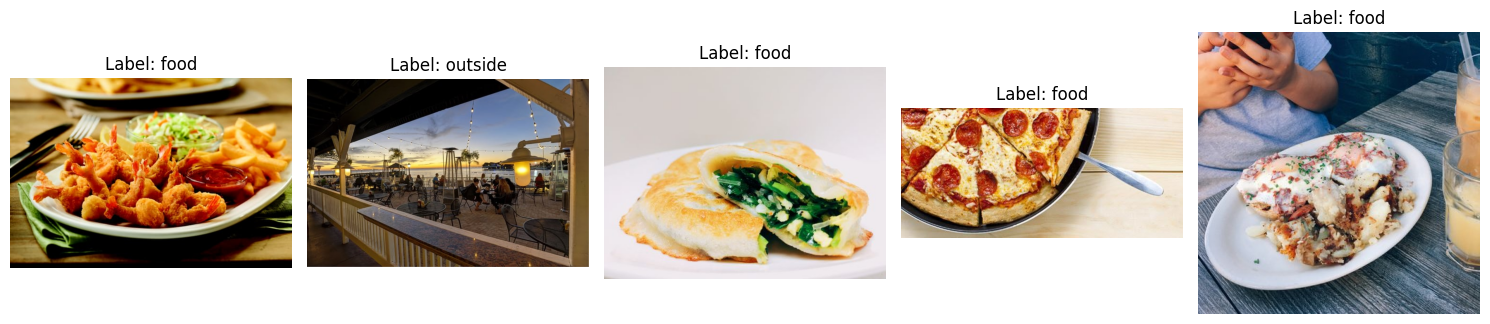

In [10]:
def show_sample_images(data, photos_folder, num_samples=5):
    # Randomly select samples from the dataset
    samples = random.sample(data, num_samples)

    # Create a plot
    plt.figure(figsize=(15, 10))

    for i, entry in enumerate(samples):
        photo_id = entry['photo_id']
        label = entry['label']
        img_path = os.path.join(photos_folder, photo_id + '.jpg')

        # Load the image
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB for visualization

        # Display the image with its label
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img)
        plt.title(f"Label: {label}", fontsize=12)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Call the function to display images
show_sample_images(data, photos_folder, num_samples=5)


In this sample we can see 5 images and the label associated, so we can give us an idea of the type of images and clases present in the dataset

In [11]:
classes=[]
for i,entry in enumerate(data):
    label = entry['label']
    classes.append(label)

set(classes)

{'drink', 'food', 'inside', 'menu', 'outside'}

We can see the dataset contains 5 different classes: 'drink', 'food', 'inside', 'menu', 'outside'

Check for data imbalance

In [12]:
df = pd.DataFrame(data)
label_counts = df['label'].value_counts()
label_counts


label
food       108152
inside      56031
outside     18569
drink       15670
menu         1678
Name: count, dtype: int64

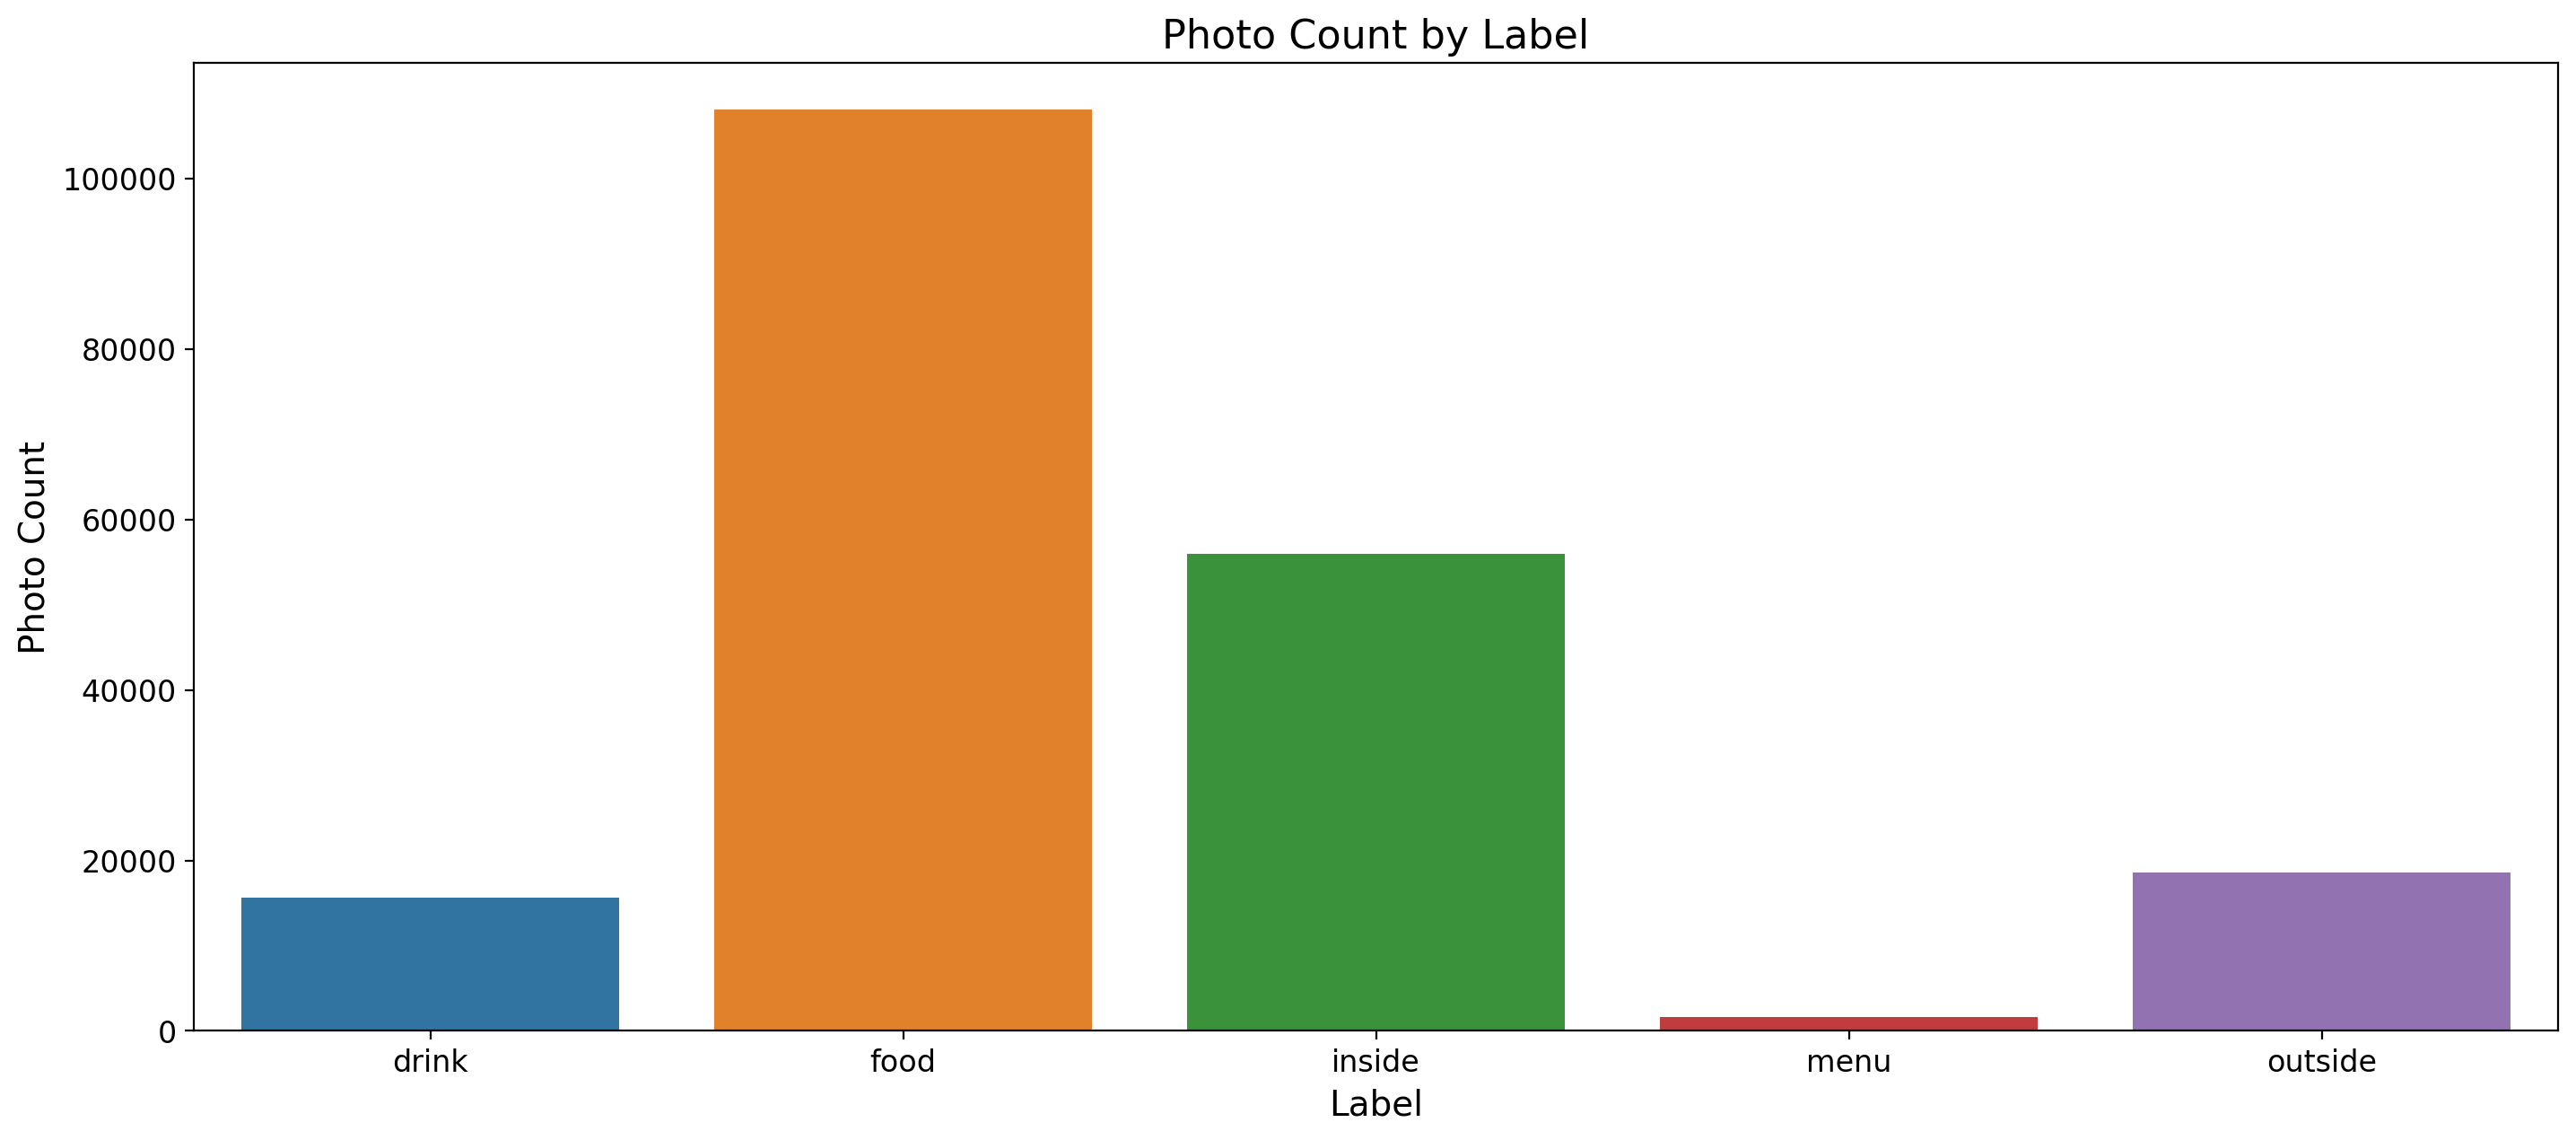

In [13]:
plt.figure(figsize=[17, 7],dpi=200)
sns.barplot(data=df.groupby('label')['photo_id'].count().to_frame().reset_index(),x='label', hue='label', y='photo_id')
plt.title("Photo Count by Label", fontsize=16)
plt.xlabel("Label", fontsize=14)
plt.ylabel("Photo Count", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

We can appreciate the menu class is being underrepresented, so before training we will perform data augmentation. 

# Preprocessing

## Adjust and normalize image resolution

In [42]:
# TARGET_SIZE = (224, 224)

# resized_folder = 'Dataset/preprocessed_photos_resized'
# os.makedirs(resized_folder, exist_ok=True)

# # Resize images
# for entry in sampled_data_list:  
#     photo_id = entry['photo_id']
#     img_path = os.path.join(photos_folder, photo_id + '.jpg')

#     try:
#         img = cv2.imread(img_path)  # Load in original color
#         if img is None:
#             print(f"Unreadable image: {img_path}")
#             continue

#         # Resize the image
#         img_resized = cv2.resize(img, TARGET_SIZE, interpolation=cv2.INTER_AREA)

#         # Save the resized image
        
#         save_path = os.path.join(resized_folder, photo_id + '_resized.jpg')
#         cv2.imwrite(save_path, img_resized)

#     except Exception as e:
#         print(f"Error processing {img_path}: {e}")

# print("Resizing completed and images saved.")


## Intensity Thresholding

In [45]:
# # List to store corrupted image IDs
# corrupted_ids = []
# resized_photos_folder = 'Dataset/preprocessed_photos_resized'
# preprocessed_folder =  'Dataset/preprocessed_photos'
# os.makedirs(preprocessed_folder, exist_ok=True)
# # Apply intensity thresholding to all images
# for entry in sampled_data_list[:]:  # Use [:] to avoid modifying the list while iterating+ '_resized.jpg'
#     photo_id = entry['photo_id']
#     img_path = os.path.join(resized_photos_folder, photo_id + '_resized.jpg')

#     try:
#         img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Read image in grayscal
#         if img is None:
#             raise ValueError("Unreadable image")  # Manually raise an exception for handling
        
#         # Normalize intensity (scaling pixel values between 0 and 255)
#         img_normalized = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
#         # Apply binary thresholding
#         _, img_thresholded = cv2.threshold(img_normalized, 128, 255, cv2.THRESH_BINARY) 
#         # Save the thresholded image
#         save_path = os.path.join(preprocessed_folder, photo_id + '_thresholded.jpg')
#         cv2.imwrite(save_path, img_thresholded)

#     except Exception as e:
#         print(f"Corrupted image detected: {img_path}")
#         corrupted_ids.append(photo_id)

# # Remove corrupted entries from sampled data
# sampled_data_list = [entry for entry in sampled_data_list if entry['photo_id'] not in corrupted_ids]

# # Print summary
# print(f"Removed {len(corrupted_ids)} corrupted images.")
# print("Intensity thresholding completed and images saved.")


In [47]:
# # Apply histogram equalization to all thresholded images
# for entry in sampled_data_list:  # Only process the cleaned dataset
#     photo_id = entry['photo_id']
#     img_path = os.path.join(preprocessed_folder, photo_id + '_thresholded.jpg')  # Use thresholded images

#     try:
#         img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Read image in grayscale
#         if img is None:
#             raise ValueError("Unreadable image")

#         # Apply histogram equalization
#         img_equalized = cv2.equalizeHist(img)

#         # Save the equalized image
#         save_path = os.path.join(preprocessed_folder, photo_id + '_equalized.jpg')
#         cv2.imwrite(save_path, img_equalized)

#     except Exception as e:
#         print(f"Error processing {img_path}: {e}")

# print("Histogram equalization completed and images saved.")


In [49]:
# # Apply Gaussian blur to all histogram-equalized images
# for entry in sampled_data_list:  # Only process the cleaned dataset
#     photo_id = entry['photo_id']
#     img_path = os.path.join(preprocessed_folder, photo_id + '_equalized.jpg')  # Use equalized images

#     try:
#         img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Read image in grayscale
#         if img is None:
#             raise ValueError("Unreadable image")

#         # Apply Gaussian Blur (kernel size 5x5)
#         img_blurred = cv2.GaussianBlur(img, (5, 5), 0)

#         # Save the blurred image
#         save_path = os.path.join(preprocessed_folder, photo_id + '_blurred.jpg')
#         cv2.imwrite(save_path, img_blurred)

#     except Exception as e:
#         print(f"Error processing {img_path}: {e}")

# print("Gaussian blur applied and images saved.")


# Functions

In [14]:
def ROC(X_test,y_test, model):
    lb = LabelBinarizer()
    y_test_bin = lb.fit_transform(y_test)
    y_pred_proba = model.predict_proba(X_test)
    
    # Compute AUC for each class
    auc_score = roc_auc_score(y_test_bin, y_pred_proba, multi_class='ovr')
    print(f"Multi-Class AUC Score: {auc_score:.4f}")
    
    # Compute ROC curve and AUC for each class
    plt.figure(figsize=(10,7))
    
    for i in range(y_test_bin.shape[1]):  # Iterate through each class
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
        roc_auc = auc(fpr, tpr)
    
        # Plot ROC curve
        plt.plot(fpr, tpr, label=f'Class {lb.classes_[i]} (AUC = {roc_auc:.2f})')
    
    # Plot random guess line
    plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
    
    # Labels and title
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multi-Class ROC Curve')
    plt.legend(loc="lower right")
    plt.show()

In [15]:
def conf_matrix(y_test,y_pred):
    cm = confusion_matrix(y_test, y_pred)
    # Plot Confusion Matrix
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

# EficientNet Transfer Learning 1

In [57]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [58]:
photos_df = pd.read_json(json_path, lines=True)

In [61]:
photos_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200100 entries, 0 to 200099
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   photo_id     200100 non-null  object
 1   business_id  200100 non-null  object
 2   caption      200100 non-null  object
 3   label        200100 non-null  object
dtypes: object(4)
memory usage: 6.1+ MB


In [63]:
# Ensure TensorFlow uses GPU
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)  # Prevent full memory allocation
        tf.config.set_visible_devices(gpus[0], 'GPU')
        print("✅ GPU is now being used for TensorFlow!")
    except RuntimeError as e:
        print(e)

✅ GPU is now being used for TensorFlow!


### Filter Valid Images using GPU and TF

In [66]:
# def filter_valid_images(photo_ids, img_dir):
# #    """Check for missing/corrupt images and return a cleaned DataFrame."""
#     valid_photo_ids = []
#     invalid_photo_ids = []
# #
#     for photo_id in photo_ids:
#         img_path = os.path.join(img_dir, f"{photo_id}.jpg")
#         if os.path.exists(img_path):
#             try:
#                 img = tf.io.read_file(img_path)
#                 img = tf.image.decode_jpeg(img, channels=3)  # Try decoding to detect corruption
#                 valid_photo_ids.append(photo_id)
#             except tf.errors.InvalidArgumentError:
#                 invalid_photo_ids.append(photo_id)

#     print(f"✅ {len(valid_photo_ids)} valid images, ❌ {len(invalid_photo_ids)} corrupt images removed.")
#     return valid_photo_ids

# # Filter the dataset and update the DataFrame
# valid_photo_ids = filter_valid_images(photos_df["photo_id"], "Dataset/photos")
# cleaned_photos_df = photos_df[photos_df["photo_id"].isin(valid_photo_ids)].reset_index(drop=True)

# ## Save cleaned DataFrame
# cleaned_photos_df.to_csv("cleaned_photos.csv", index=False)

cleaned_photos_df = pd.read_csv("cleaned_photos.csv")

### Load Image in batches with TF

In [69]:
def load_images_with_tf(photo_ids, labels, img_dir, IMAGE_SIZE=(224, 224), batch_size=256):
    """Load images and labels using tf.data, handling corrupt images."""
    
    image_paths = [os.path.join(img_dir, f"{photo_id}.jpg") for photo_id in photo_ids]
    
    def load_image_label(image_path, label):
        """Load and preprocess a single image while handling corrupt images."""
        img = tf.io.read_file(image_path)
        
        try:
            img = tf.image.decode_jpeg(img, channels=3)
            img = tf.image.resize(img, IMAGE_SIZE)
            
            # Ensure dtype is uint8 before converting
            img = tf.cast(img, tf.float32) / 255.0  # Normalize to [0,1]
            
            return img, label  # Return image + label
        except tf.errors.InvalidArgumentError:
            print(f"Skipping corrupt image: {image_path}")
            return tf.zeros((IMAGE_SIZE[0], IMAGE_SIZE[1], 3)), label  # Keep batch shape consistent

    # Create a TensorFlow Dataset with GPU acceleration
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    dataset = dataset.map(load_image_label, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return dataset

In [71]:
from sklearn.preprocessing import LabelEncoder
# Convert labels to integers
label_encoder = LabelEncoder()
cleaned_photos_df["label"] = label_encoder.fit_transform(cleaned_photos_df["label"])

# Save the mapping (optional, useful for later decoding)
label_mapping = dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))
print("Label Mapping:", label_mapping)

Label Mapping: {'drink': 0, 'food': 1, 'inside': 2, 'menu': 3, 'outside': 4}


In [73]:
# Extract photo IDs from DataFrame
photo_ids = cleaned_photos_df["photo_id"].tolist()

# Split into 80% train, 20% validation
train_ids, val_ids = train_test_split(photo_ids, test_size=0.2, random_state=42)

# Create new DataFrames
train_df = cleaned_photos_df[cleaned_photos_df["photo_id"].isin(train_ids)].reset_index(drop=True)
val_df = cleaned_photos_df[cleaned_photos_df["photo_id"].isin(val_ids)].reset_index(drop=True)

In [75]:
train_dataset = load_images_with_tf(train_df["photo_id"], train_df["label"], "Dataset/photos", batch_size=256)
val_dataset = load_images_with_tf(val_df["photo_id"], val_df["label"], "Dataset/photos", batch_size=256)

In [77]:
train_dataset = train_dataset.map(lambda x, y: (x, tf.one_hot(y, depth=5)))
val_dataset = val_dataset.map(lambda x, y: (x, tf.one_hot(y, depth=5)))

In [79]:
for images, labels in train_dataset.take(1):
    print("Image batch shape:", images.shape)  # Expected: (batch_size, 224, 224, 3)
    print("Label batch shape:", labels.shape)  # Expected: (batch_size,)
    print("First label:", labels[0].numpy())  # Ensure labels exist

Image batch shape: (256, 224, 224, 3)
Label batch shape: (256, 5)
First label: [0. 0. 1. 0. 0.]


### Load base model and add output dense layers

In [82]:
#Load EfficientNet without top layers
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

Here we are loading EfficientNet B0 which is the most light and efficient model, using imagenet weights which were trained for 1000 different classes, we are removing the last dense layer so we can add our own dense layer for our classes.

In [84]:
# Freeze the base model initially
base_model.trainable = False

We freeze the convolution architecture so we can connect our own output dense layer. 

In [88]:
# Create the image processing branch
image_input = Input(shape=(224, 224, 3), name="image_input")
x = base_model(image_input, training=False)  # Ensures frozen layers remain frozen
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)  # Dense layer for feature extraction

* Here we define the input shape and name
* We are adding a pooling layer to extract the average of each channel of the image and reduce the parameters number, also avoiding overfitting.
* Also we add a dense layer of 128 neuronswith Relu activation so we can introduce non linearity to the model and thus we can let the model learn more complex representations of our images also reducing the parameters of the next dense layers. 

In [91]:
# Fully connected layers
x = Dense(64, activation="relu")(x)
x = Dense(32, activation="relu")(x)
output = Dense(5, activation="softmax")(x)  # Adjust output layer for classification

This is the resulting output shape of our network 128 → 64 → 32 → 5

In [94]:
# Create the final model
model = Model(inputs=image_input, outputs=output)

In [96]:
# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss="binary_crossentropy",
              metrics=["accuracy"])

# Print model summary
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 image_input (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 efficientnetb0 (Functional)  (None, 7, 7, 1280)       4049571   
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 128)               163968    
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                             

### Fine Tuning

In [99]:
# Fine-tuning: Unfreeze top layers of EfficientNet
base_model.trainable = True
for layer in base_model.layers[:-20]:  # Unfreeze the last 20 layers
    layer.trainable = False
    def freeze(model):
        """Freeze model weights in every layer."""
        for layer in model.layers:
            layer.trainable = False
    
            if isinstance(layer, models.Model):
                freeze(layer)

In [101]:
# Recompile after unfreezing
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

Lets compare our inputs and expected outputs shapes for our model and dataset

In [104]:
print(model.output_shape)

(None, 5)


In [106]:
for x, y in train_dataset.take(1):
    print(x.shape, y.shape)  # Should match model output

(256, 224, 224, 3) (256, 5)


### Train Model

In [109]:
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
import datetime
import time

# Iniciar el temporizador
start_time = time.time()


# Define Early Stopping Callback
early_stop = EarlyStopping(
    monitor="val_loss",  
    patience=7,  
    restore_best_weights=True,
    verbose=1
)

# Train the CNN model
history = model.fit(
    train_dataset,
    epochs=25,  
    validation_data=val_dataset,  
    callbacks=[early_stop]
)

# Finalizar el temporizador
end_time = time.time()

Epoch 1/25
625/625 [==============================] - 307s 472ms/step - loss: 1.1584 - accuracy: 0.5330 - val_loss: 1.0833 - val_accuracy: 0.5789
Epoch 2/25
625/625 [==============================] - 306s 490ms/step - loss: 1.0599 - accuracy: 0.5774 - val_loss: 1.0212 - val_accuracy: 0.5927
Epoch 3/25
625/625 [==============================] - 2900s 5s/step - loss: 1.0219 - accuracy: 0.5989 - val_loss: 0.9874 - val_accuracy: 0.6149
Epoch 4/25
625/625 [==============================] - 1095s 2s/step - loss: 0.9800 - accuracy: 0.6281 - val_loss: 0.9119 - val_accuracy: 0.6673
Epoch 5/25
625/625 [==============================] - 290s 464ms/step - loss: 0.9284 - accuracy: 0.6577 - val_loss: 0.8727 - val_accuracy: 0.6848
Epoch 6/25
625/625 [==============================] - 289s 463ms/step - loss: 0.8942 - accuracy: 0.6714 - val_loss: 0.8470 - val_accuracy: 0.6949
Epoch 7/25
625/625 [==============================] - 289s 462ms/step - loss: 0.8698 - accuracy: 0.6816 - val_loss: 0.8304 - val

In [113]:
# Calcular el tiempo total en minutos y segundos
total_time = end_time - start_time
minutes = int(total_time // 60)
seconds = int(total_time % 60)

print(f" Training time: {minutes} min {seconds} seg")

# Training time: 178 min 37 seg

 Training time: 178 min 37 seg


### Save Weights

In [115]:
from keras import models
def freeze(model):
    """Freeze model weights in every layer."""
    for layer in model.layers:
        layer.trainable = False

        if isinstance(layer, models.Model):
            freeze(layer)
# Guardar los pesos en formato HDF5
model.save_weights('EN_1_weights.h5', save_format='h5')

In [117]:
# base_model = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
# image_input = Input(shape=(224, 224, 3), name="image_input")
# x = base_model(image_input, training=False)  # Ensures frozen layers remain frozen
# x = GlobalAveragePooling2D()(x)
# x = Dense(128, activation="relu")(x)  # Dense layer for feature extraction
# # Fully connected layers
# x = Dense(64, activation="relu")(x)
# x = Dense(32, activation="relu")(x)
# output = Dense(5, activation="softmax")(x)  # Adjust output layer for classification
# # Create the final model
# model_loaded = Model(inputs=image_input, outputs=output)
# # Compile the model
# model_loaded.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
#               loss="binary_crossentropy",
#               metrics=["accuracy"])
# model_loaded.load_weights('EN_1_weights.h5')

# # Print model summary
# model_loaded.summary()



We are unable to save and reload the models as described in this issue: https://github.com/tensorflow/tpu/issues/378

### Model Evaluation

In [121]:
train_loss, train_accuracy = model.evaluate(train_dataset)
print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Train Loss: {train_loss:.4f}")

val_loss, val_accuracy = model.evaluate(val_dataset)
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Validation Loss: {val_loss:.4f}")


625/625 [==============================] - 230s 367ms/step - loss: 0.6969 - accuracy: 0.7412
Train Accuracy: 0.7412
Train Loss: 0.6969
157/157 [==============================] - 57s 365ms/step - loss: 0.6942 - accuracy: 0.7449
Validation Accuracy: 0.7449
Validation Loss: 0.6942


It can be appreciated that the model is generalizing well and it's not under/overfitting

In [122]:
y_true = np.concatenate([y for x, y in val_dataset], axis=0) #np.concatenate([y.numpy() for _, y in val_dataset], axis=0)
y_pred = model.predict(val_dataset) 
y_pred_classes = np.argmax(y_pred, axis=1)

157/157 [==============================] - 59s 364ms/step


In [124]:
y_true_labels = np.argmax(y_true, axis=1)
y_true_labels

array([1, 2, 1, ..., 2, 2, 2], dtype=int64)

In [129]:
y_pred_classes

array([1, 2, 1, ..., 2, 2, 2], dtype=int64)

In [137]:
print(classification_report(y_true_labels, y_pred_classes, zero_division=0))

              precision    recall  f1-score   support

           0       0.52      0.07      0.12      3081
           1       0.80      0.95      0.87     21726
           2       0.64      0.78      0.71     11179
           3       0.00      0.00      0.00       324
           4       0.84      0.07      0.13      3689

    accuracy                           0.74     39999
   macro avg       0.56      0.37      0.36     39999
weighted avg       0.73      0.74      0.69     39999



The model is struggling with the drinks, menu and outside images, it's clearly biased by the food class. 
EN1 = Accuracy = 0.74

In [133]:
print("Label Mapping:", label_mapping)

Label Mapping: {'drink': 0, 'food': 1, 'inside': 2, 'menu': 3, 'outside': 4}


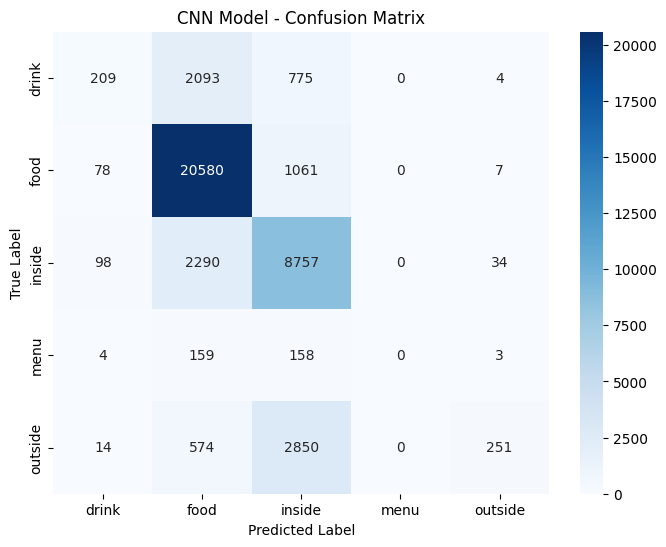

In [135]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


y_true_labels = np.argmax(y_true, axis=1)
y_true_labels

# Generate Confusion Matrix
cm = confusion_matrix(y_true_labels, y_pred_classes)

# Plot Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("CNN Model - Confusion Matrix")
plt.show()

157/157 [==============================] - 54s 346ms/step


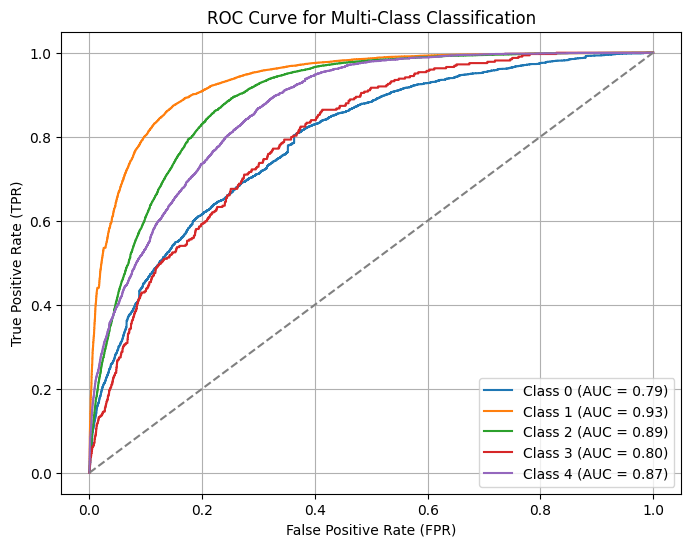

In [144]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Extract ground-truth labels (`y_true`) from val_dataset
y_true = np.concatenate([y.numpy() for _, y in val_dataset], axis=0)

# Get model-predicted probabilities
y_pred_prob = model.predict(val_dataset)  # Outputs probability distribution per class

# Ensure both arrays have the same number of samples
assert y_true.shape[0] == y_pred_prob.shape[0], "Mismatch in number of samples!"

# Binarize labels (One-vs-Rest) for multi-class ROC
n_classes = y_pred_prob.shape[1]  # Number of classes
y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

# Ensure shapes match before proceeding
assert y_true_bin.shape == y_pred_prob.shape, "Shape mismatch in label binarization!"

# Create a figure
plt.figure(figsize=(8, 6))

# Compute and plot the ROC curve for each class
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

# Plot reference line (random classification)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

# Configure the plot
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve for Multi-Class Classification")
plt.legend(loc="lower right")
plt.grid()
plt.show()


In [140]:
print("Label Mapping:", label_mapping)

Label Mapping: {'drink': 0, 'food': 1, 'inside': 2, 'menu': 3, 'outside': 4}


### Lime

In [146]:
def predict_proba_for_lime(images):
    """Función de predicción adaptada para LIME, que devuelve probabilidades."""
    if isinstance(images, list):  
        images = np.array(images)
    return model.predict(images)  
    
for img_batch, label_batch in val_dataset.take(1):  # Toma un batch
    test_image = img_batch[0].numpy()  # Extrae una imagen del batch
    true_label = np.argmax(label_batch[0].numpy())  # Convierte one-hot a índice
    break 

In [150]:
from lime import lime_image
from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt

explainer = lime_image.LimeImageExplainer()

explanation = explainer.explain_instance(
    test_image,  
    predict_proba_for_lime, 
    labels=[true_label],  
    hide_color=0, 
    num_samples=300
)

print("Top labels explained:", explanation.top_labels)


  0%|                                                                                          | 0/300 [00:00<?, ?it/s]

1/1 [==============================] - 1s 1s/step


  3%|██▋                                                                              | 10/300 [00:01<00:47,  6.07it/s]

1/1 [==============================] - 0s 16ms/step


 10%|████████                                                                         | 30/300 [00:01<00:13, 20.54it/s]

...

1/1 [==============================] - 0s 23ms/step


 96%|███████████████████████████████████████████████████████████████████████████▌   | 287/300 [00:03<00:00, 129.86it/s]

1/1 [==============================] - 0s 40ms/step


100%|████████████████████████████████████████████████████████████████████████████████| 300/300 [00:04<00:00, 74.31it/s]

Top labels explained: [1, 0, 2, 3, 4]


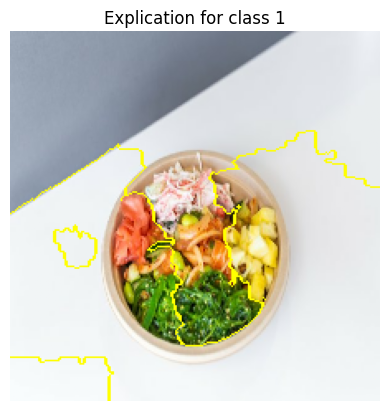

In [152]:
# Obtener la imagen con la máscara resaltando las regiones más importantes
temp, mask = explanation.get_image_and_mask(
    label=true_label,  # Explicar la etiqueta real
    positive_only=True,  # Solo mostrar contribuciones positivas
    num_features=10,  # Cantidad de superpixeles destacados
    hide_rest=False  # Mostrar el resto de la imagen
)

# Mostrar la imagen con los superpixeles resaltados
plt.imshow(mark_boundaries(temp, mask))
plt.title(f"Explication for class {true_label}")
plt.axis("off")
plt.show()


In [154]:
proba = model.predict(test_image[np.newaxis, ...])  #Batch dimension
print(f"Predicted probabilities: {proba}")
print(f"True label probability: {proba[0, true_label]}")
print("Label Mapping:", label_mapping)

1/1 [==============================] - 0s 81ms/step
Predicted probabilities: [[0.03462205 0.9589016  0.00433338 0.00110981 0.00103314]]
True label probability: 0.958901584148407
Label Mapping: {'drink': 0, 'food': 1, 'inside': 2, 'menu': 3, 'outside': 4}


Again we can confirm the model is very certain when it's food, this can be due to the class imbalance which will be treated on the next iterations. 

| Task                          | Sub-task                                           | Comments |
|-------------------------------|----------------------------------------------------|----------|
| **Data Preprocessing**         | Scaling and Resizing                              | Done |
|                                | Image Augmentation                               | Done/Not Done |
|                                | Train and test data handled correctly            | Done |
|                                | Gaussian Blur, Histogram Equalization and Intensity thresholds | Done/Not Done |
| **Model Trained**              | Training Time?   178 min 37 seg                  | Done |
|                                | AUC and Confusion Matrix Computed                | Done, Train Accuracy: 0.7412/Validation Accuracy: 0.7449 |
|                                | Overfitting/Underfitting checked and handled     | Done |
| **Empirical Tuning**           | Interpretability Implemented                     | Major Findings: The model is struggling with class imbalance |
| **1st Round of Tuning**        | Class imbalance, performance /                                 |  |
| **2nd Round of Tuning**        | Issue Faced/Fixed                                |  |


# EficientNet Transfer Learning 2

In [16]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [17]:
photos_df = pd.read_json(json_path, lines=True)

In [18]:
photos_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200100 entries, 0 to 200099
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   photo_id     200100 non-null  object
 1   business_id  200100 non-null  object
 2   caption      200100 non-null  object
 3   label        200100 non-null  object
dtypes: object(4)
memory usage: 6.1+ MB


In [19]:
# Ensure TensorFlow uses GPU
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)  # Prevent full memory allocation
        tf.config.set_visible_devices(gpus[0], 'GPU')
        print("✅ GPU is now being used for TensorFlow!")
    except RuntimeError as e:
        print(e)

✅ GPU is now being used for TensorFlow!


### Filter Valid Images using GPU and TF

In [20]:
# def filter_valid_images(photo_ids, img_dir):
# #    """Check for missing/corrupt images and return a cleaned DataFrame."""
#     valid_photo_ids = []
#     invalid_photo_ids = []
# #
#     for photo_id in photo_ids:
#         img_path = os.path.join(img_dir, f"{photo_id}.jpg")
#         if os.path.exists(img_path):
#             try:
#                 img = tf.io.read_file(img_path)
#                 img = tf.image.decode_jpeg(img, channels=3)  # Try decoding to detect corruption
#                 valid_photo_ids.append(photo_id)
#             except tf.errors.InvalidArgumentError:
#                 invalid_photo_ids.append(photo_id)

#     print(f"✅ {len(valid_photo_ids)} valid images, ❌ {len(invalid_photo_ids)} corrupt images removed.")
#     return valid_photo_ids

# # Filter the dataset and update the DataFrame
# valid_photo_ids = filter_valid_images(photos_df["photo_id"], "Dataset/photos")
# cleaned_photos_df = photos_df[photos_df["photo_id"].isin(valid_photo_ids)].reset_index(drop=True)

# ## Save cleaned DataFrame
# cleaned_photos_df.to_csv("cleaned_photos.csv", index=False)

cleaned_photos_df = pd.read_csv("cleaned_photos.csv")

### Handle Class Imbalance

In [21]:
# import pandas as pd
# import tensorflow as tf
# import os
# import cv2
# import numpy as np
# from tqdm import tqdm

# # Cargar el CSV original
# df = pd.read_csv("cleaned_photos.csv")

# # Definir carpeta de salida
# output_dir = "Dataset/photos_balanced"
# os.makedirs(output_dir, exist_ok=True)

# # Obtener la cantidad máxima de imágenes por clase
# class_counts = df["label"].value_counts()
# max_samples = class_counts.max()

# # Nuevo DataFrame para almacenar las imágenes balanceadas
# balanced_data = []

# # Función de aumento de datos
# def augment_image(image):
#     """Aplica aumentaciones a la imagen."""
#     image = tf.image.random_flip_left_right(image)
#     image = tf.image.random_brightness(image, max_delta=0.1)
#     image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
#     image = tf.image.resize_with_crop_or_pad(image, 230, 230)
#     image = tf.image.random_crop(image, size=[224, 224, 3])
#     image = tf.image.rot90(image, k=tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32))
#     return image.numpy()

# # Procesar cada clase
# for label, count in tqdm(class_counts.items(), desc="Balancing classes"):
#     class_df = df[df["label"] == label]
#     num_samples_needed = max_samples - count

#     for _, row in class_df.iterrows():
#         photo_id = row["photo_id"]
#         image_path = f"Dataset/photos/{photo_id}.jpg"

#         # Verificar si la imagen existe
#         if os.path.exists(image_path):
#             image = cv2.imread(image_path)
#             image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convertir a RGB
#             image = cv2.resize(image, (224, 224))  # Asegurar tamaño correcto
            
#             # Guardar imagen original en el nuevo folder
#             new_photo_id = f"{photo_id}_orig"
#             cv2.imwrite(os.path.join(output_dir, f"{new_photo_id}.jpg"), cv2.cvtColor(image, cv2.COLOR_RGB2BGR))
#             balanced_data.append([new_photo_id, "", "", label])  # Dejar business_id y caption en blanco

#             # Aplicar data augmentation para balancear la clase
#             for i in range(num_samples_needed // count + 1):  # Para balancear
#                 augmented_image = augment_image(tf.convert_to_tensor(image, dtype=tf.float32))

#                 new_photo_id = f"{photo_id}_aug{i}"
#                 cv2.imwrite(os.path.join(output_dir, f"{new_photo_id}.jpg"), cv2.cvtColor(augmented_image, cv2.COLOR_RGB2BGR))
#                 balanced_data.append([new_photo_id, "", "", label])  # Agregar al nuevo dataset

# Guardar el nuevo CSV con las imágenes balanceadas
#balanced_df = pd.DataFrame(balanced_data, columns=["photo_id", "business_id", "caption", "label"])
#balanced_df.to_csv("cleaned_photos_balanced.csv", index=False)

In [22]:
# # Load the dataset
# cleaned_photos_balanced_bad = pd.read_csv("cleaned_photos_balanced.csv")

# # Get class distribution
# class_counts = cleaned_photos_balanced_bad["label"].value_counts()
# max_allowed = min(class_counts.values)  # Use second most common class as baseline

# # Identify extra images from class 1 (food)
# if class_counts.get("food", 0) > max_allowed:
#     drop_class_1 = cleaned_photos_balanced_bad[cleaned_photos_balanced_bad["label"] == "food"].sample(
#         n=class_counts.get("food", 0) - max_allowed, random_state=42
#     ).index
#     cleaned_photos_balanced_bad = cleaned_photos_balanced_bad.drop(index=drop_class_1)

# # Save the cleaned dataset
# cleaned_photos_balanced_bad.to_csv("cleaned_photos_balanced_final.csv", index=False)

# print("Final dataset saved with excess class 1 images removed.")

In [23]:
cleaned_photos_balanced = pd.read_csv("cleaned_photos_balanced_final.csv")

In [24]:
class_counts = cleaned_photos_balanced["label"].value_counts()
class_counts

label
inside     112060
outside    111414
drink      109690
food       109070
menu       109070
Name: count, dtype: int64

### Load Image in batches with TF

In [25]:
def load_images_with_tf(photo_ids, labels, img_dir, IMAGE_SIZE=(224, 224), batch_size=256):
    """Load images and labels using tf.data, handling corrupt images."""
    
    image_paths = [os.path.join(img_dir, f"{photo_id}.jpg") for photo_id in photo_ids]
    
    def load_image_label(image_path, label):
        """Load and preprocess a single image while handling corrupt images."""
        img = tf.io.read_file(image_path)
        
        try:
            img = tf.image.decode_jpeg(img, channels=3)
            img = tf.image.resize(img, IMAGE_SIZE)
            
            # Ensure dtype is uint8 before converting
            img = tf.cast(img, tf.float32) / 255.0  # Normalize to [0,1]
            
            return img, label  # Return image + label
        except tf.errors.InvalidArgumentError:
            print(f"Skipping corrupt image: {image_path}")
            return tf.zeros((IMAGE_SIZE[0], IMAGE_SIZE[1], 3)), label  # Keep batch shape consistent

    # Create a TensorFlow Dataset with GPU acceleration
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    dataset = dataset.map(load_image_label, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return dataset

### Do Label Encoder to the Labels

In [28]:
from sklearn.preprocessing import LabelEncoder
# Convert labels to integers
label_encoder = LabelEncoder()
cleaned_photos_balanced["label"] = label_encoder.fit_transform(cleaned_photos_balanced["label"])

# Save the mapping (optional, useful for later decoding)
label_mapping = dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))
print("Label Mapping:", label_mapping)

Label Mapping: {'drink': 0, 'food': 1, 'inside': 2, 'menu': 3, 'outside': 4}


In [29]:
# Extract photo IDs from DataFrame
photo_ids = cleaned_photos_balanced["photo_id"].tolist()

# Split into 80% train, 20% validation
train_ids, val_ids = train_test_split(photo_ids, test_size=0.2, random_state=42)

# Create new DataFrames
train_df = cleaned_photos_balanced[cleaned_photos_balanced["photo_id"].isin(train_ids)].reset_index(drop=True)
val_df = cleaned_photos_balanced[cleaned_photos_balanced["photo_id"].isin(val_ids)].reset_index(drop=True)

In [30]:
class_counts = train_df["label"].value_counts().to_dict()
print(class_counts)

{2: 89676, 4: 89252, 0: 87701, 3: 87214, 1: 87201}


In [31]:
train_dataset_balanced = load_images_with_tf(train_df["photo_id"], train_df["label"], "Dataset/photos_balanced", batch_size=256)
val_dataset = load_images_with_tf(val_df["photo_id"], val_df["label"], "Dataset/photos_balanced", batch_size=256)

In [32]:
for images, labels in train_dataset_balanced.take(1):
    print(images.shape, labels.shape)

(256, 224, 224, 3) (256,)


In [33]:
train_dataset_balanced = train_dataset_balanced.map(lambda x, y: (x, tf.one_hot(y, depth=5)))
val_dataset = val_dataset.map(lambda x, y: (x, tf.one_hot(y, depth=5)))

In [34]:
for images, labels in train_dataset_balanced.take(1):
    #print(images[0])
    print(labels[1])

tf.Tensor([0. 1. 0. 0. 0.], shape=(5,), dtype=float32)


In [35]:
for images, labels in train_dataset_balanced.take(1):
    print("Image batch shape:", images.shape)  # Expected: (batch_size, 224, 224, 3)
    print("Label batch shape:", labels.shape)  # Expected: (batch_size,)
    print("First label:", labels[0].numpy())  # Ensure labels exist

Image batch shape: (256, 224, 224, 3)
Label batch shape: (256, 5)
First label: [0. 1. 0. 0. 0.]


### Load base model and add output dense layers

In [36]:
#Load EfficientNet without top layers
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

Here we are loading EfficientNet B0 which is the most light and efficient model, using imagenet weights which were trained for 1000 different classes, we are removing the last dense layer so we can add our own dense layer for our classes.

In [37]:
# Freeze the base model initially
base_model.trainable = False

We freeze the convolution architecture so we can connect our own output dense layer. 

In [38]:
# Create the image processing branch
image_input = Input(shape=(224, 224, 3), name="image_input")
x = base_model(image_input, training=False)  # Ensures frozen layers remain frozen
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)  # Dense layer for feature extraction

* Here we define the input shape and name
* We are adding a pooling layer to extract the average of each channel of the image and reduce the parameters number, also avoiding overfitting.
* Also we add a dense layer of 128 neuronswith Relu activation so we can introduce non linearity to the model and thus we can let the model learn more complex representations of our images also reducing the parameters of the next dense layers. 

In [39]:
# Fully connected layers
x = Dense(64, activation="relu")(x)
x = Dense(32, activation="relu")(x)
output = Dense(5, activation="softmax")(x)  # Adjust output layer for classification

This is the resulting output shape of our network 128 → 64 → 32 → 5

In [40]:
# Create the final model
model = Model(inputs=image_input, outputs=output)

In [41]:
# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss="binary_crossentropy",
              metrics=["accuracy"])

# Print model summary
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 image_input (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 efficientnetb0 (Functional)  (None, 7, 7, 1280)       4049571   
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 128)               163968    
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                             

### Fine Tuning

In [42]:
# Fine-tuning: Unfreeze top layers of EfficientNet
base_model.trainable = True
for layer in base_model.layers[:-10]:  # Unfreeze the last 10 layers
    layer.trainable = False
    def freeze(model):
        """Freeze model weights in every layer."""
        for layer in model.layers:
            layer.trainable = False
    
            if isinstance(layer, models.Model):
                freeze(layer)

In [43]:
# Recompile after unfreezing
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

Lets compare our inputs and expected outputs shapes for our model and dataset

In [44]:
print(model.output_shape)

(None, 5)


In [46]:
for x, y in train_dataset_balanced.take(1):
    print(x.shape, y.shape)  # Should match model output

(256, 224, 224, 3) (256, 5)


### Train Model

In [47]:
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
import datetime
import time

# Iniciar el temporizador
start_time = time.time()


# Define Early Stopping Callback
early_stop = EarlyStopping(
    monitor="val_loss",  
    patience=7,  
    restore_best_weights=True,
    verbose=1
)

# Train the CNN model
history = model.fit(
    train_dataset_balanced,
    epochs=5,  
    validation_data=val_dataset,  
    callbacks=[early_stop]
)

# Finalizar el temporizador
end_time = time.time()

Epoch 1/5
1723/1723 [==============================] - 784s 448ms/step - loss: 0.2085 - accuracy: 0.9688 - val_loss: 8.9494 - val_accuracy: 0.1982
Epoch 2/5
1723/1723 [==============================] - 770s 447ms/step - loss: 0.3514 - accuracy: 0.9351 - val_loss: 7.6566 - val_accuracy: 0.1982
Epoch 3/5
1723/1723 [==============================] - 775s 450ms/step - loss: 0.3838 - accuracy: 0.9235 - val_loss: 6.1366 - val_accuracy: 0.1982
Epoch 4/5
1723/1723 [==============================] - 770s 447ms/step - loss: 0.3524 - accuracy: 0.9318 - val_loss: 6.5146 - val_accuracy: 0.1982
Epoch 5/5
1723/1723 [==============================] - 770s 447ms/step - loss: 0.3038 - accuracy: 0.9335 - val_loss: 6.5435 - val_accuracy: 0.1982


In [48]:
# Calcular el tiempo total en minutos y segundos
total_time = end_time - start_time
minutes = int(total_time // 60)
seconds = int(total_time % 60)

print(f" Training time: {minutes} min {seconds} seg")

# Training time: 178 min 37 seg

 Training time: 64 min 28 seg


### Save Weights

In [49]:
from keras import models
def freeze(model):
    """Freeze model weights in every layer."""
    for layer in model.layers:
        layer.trainable = False

        if isinstance(layer, models.Model):
            freeze(layer)
# Guardar los pesos en formato HDF5
model.save_weights('EN_1_weights.h5', save_format='h5')

In [50]:
# base_model = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
# image_input = Input(shape=(224, 224, 3), name="image_input")
# x = base_model(image_input, training=False)  # Ensures frozen layers remain frozen
# x = GlobalAveragePooling2D()(x)
# x = Dense(128, activation="relu")(x)  # Dense layer for feature extraction
# # Fully connected layers
# x = Dense(64, activation="relu")(x)
# x = Dense(32, activation="relu")(x)
# output = Dense(5, activation="softmax")(x)  # Adjust output layer for classification
# # Create the final model
# model_loaded = Model(inputs=image_input, outputs=output)
# # Compile the model
# model_loaded.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
#               loss="binary_crossentropy",
#               metrics=["accuracy"])
# model_loaded.load_weights('EN_1_weights.h5')

# # Print model summary
# model_loaded.summary()



We are unable to save and reload the models as described in this issue: https://github.com/tensorflow/tpu/issues/378

### Model Evaluation

In [51]:
train_loss, train_accuracy = model.evaluate(train_dataset_balanced)
print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Train Loss: {train_loss:.4f}")

val_loss, val_accuracy = model.evaluate(val_dataset)
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Validation Loss: {val_loss:.4f}")


1723/1723 [==============================] - 604s 350ms/step - loss: 6.5484 - accuracy: 0.1977
Train Accuracy: 0.1977
Train Loss: 6.5484
431/431 [==============================] - 150s 348ms/step - loss: 6.5435 - accuracy: 0.1982
Validation Accuracy: 0.1982
Validation Loss: 6.5435


It can be appreciated that the model is overfitting too much.

In [52]:
y_true = np.concatenate([y for x, y in val_dataset], axis=0) #np.concatenate([y.numpy() for _, y in val_dataset], axis=0)
y_pred = model.predict(val_dataset) 
y_pred_classes = np.argmax(y_pred, axis=1)

431/431 [==============================] - 150s 345ms/step


In [53]:
y_true_labels = np.argmax(y_true, axis=1)
y_true_labels

array([1, 1, 1, ..., 3, 3, 3], dtype=int64)

In [54]:
y_pred_classes

array([3, 3, 3, ..., 3, 3, 3], dtype=int64)

In [55]:
print(classification_report(y_true_labels, y_pred_classes, zero_division=0))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00     21990
           1       0.00      0.00      0.00     21869
           2       0.00      0.00      0.00     22385
           3       0.20      1.00      0.33     21856
           4       0.00      0.00      0.00     22162

    accuracy                           0.20    110262
   macro avg       0.04      0.20      0.07    110262
weighted avg       0.04      0.20      0.07    110262



The model is struggling with the drinks, menu and outside images, it's clearly biased by the food class. 
EN1 = Accuracy = 0.74

In [56]:
print("Label Mapping:", label_mapping)

Label Mapping: {'drink': 0, 'food': 1, 'inside': 2, 'menu': 3, 'outside': 4}


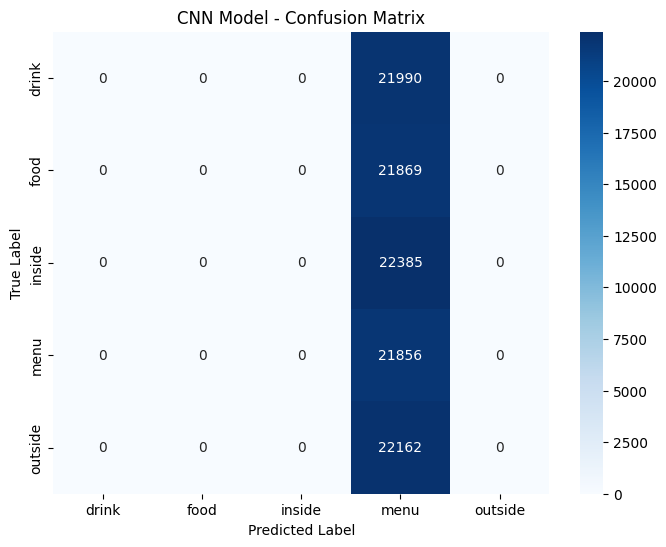

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


y_true_labels = np.argmax(y_true, axis=1)
y_true_labels

# Generate Confusion Matrix
cm = confusion_matrix(y_true_labels, y_pred_classes)

# Plot Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("CNN Model - Confusion Matrix")
plt.show()

For some reason the model is predicting everything as menu only

431/431 [==============================] - 149s 346ms/step


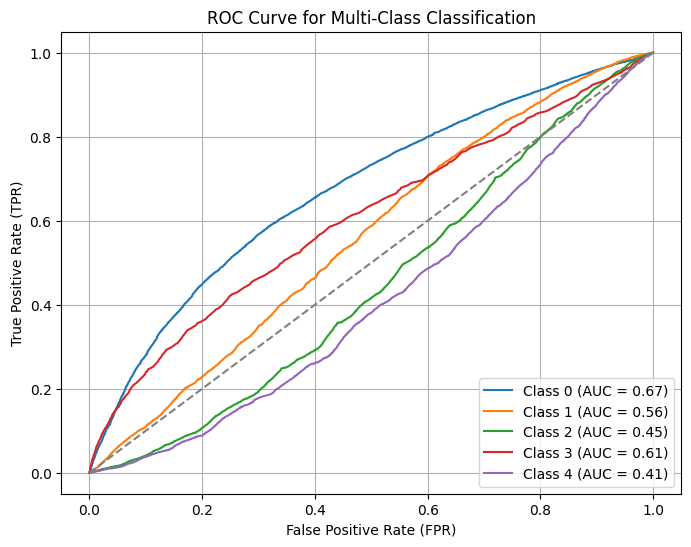

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Extract ground-truth labels (`y_true`) from val_dataset
y_true = np.concatenate([y.numpy() for _, y in val_dataset], axis=0)

# Get model-predicted probabilities
y_pred_prob = model.predict(val_dataset)  # Outputs probability distribution per class

# Ensure both arrays have the same number of samples
assert y_true.shape[0] == y_pred_prob.shape[0], "Mismatch in number of samples!"

# Binarize labels (One-vs-Rest) for multi-class ROC
n_classes = y_pred_prob.shape[1]  # Number of classes
y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

# Ensure shapes match before proceeding
assert y_true_bin.shape == y_pred_prob.shape, "Shape mismatch in label binarization!"

# Create a figure
plt.figure(figsize=(8, 6))

# Compute and plot the ROC curve for each class
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

# Plot reference line (random classification)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

# Configure the plot
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve for Multi-Class Classification")
plt.legend(loc="lower right")
plt.grid()
plt.show()


In [59]:
print("Label Mapping:", label_mapping)

Label Mapping: {'drink': 0, 'food': 1, 'inside': 2, 'menu': 3, 'outside': 4}


### Lime

In [60]:
def predict_proba_for_lime(images):
    """Función de predicción adaptada para LIME, que devuelve probabilidades."""
    if isinstance(images, list):  
        images = np.array(images)
    return model.predict(images)  
    
for img_batch, label_batch in val_dataset.take(1):  # Toma un batch
    test_image = img_batch[0].numpy()  # Extrae una imagen del batch
    true_label = np.argmax(label_batch[0].numpy())  # Convierte one-hot a índice
    break 

In [61]:
from lime import lime_image
from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt

explainer = lime_image.LimeImageExplainer()

explanation = explainer.explain_instance(
    test_image,  
    predict_proba_for_lime, 
    labels=[true_label],  
    hide_color=0, 
    num_samples=300
)

print("Top labels explained:", explanation.top_labels)


c:\Users\rooyv\anaconda3\envs\tf2.1\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  0%|                                                                                          | 0/300 [00:00<?, ?it/s]

1/1 [==============================] - 3s 3s/step


  3%|██▋                                                                              | 10/300 [00:02<01:26,  3.35it/s]

1/1 [==============================] - 0s 11ms/step


 10%|████████                                                                         | 30/300 [00:03<00:22, 11.96it/s]

...

1/1 [==============================] - 0s 33ms/step


 96%|███████████████████████████████████████████████████████████████████████████▊   | 288/300 [00:05<00:00, 106.13it/s]

1/1 [==============================] - 0s 25ms/step


100%|████████████████████████████████████████████████████████████████████████████████| 300/300 [00:05<00:00, 53.33it/s]

Top labels explained: [3, 0, 2, 4, 1]


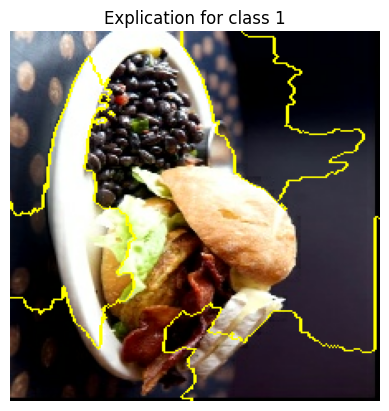

In [62]:
# Obtener la imagen con la máscara resaltando las regiones más importantes
temp, mask = explanation.get_image_and_mask(
    label=true_label,  # Explicar la etiqueta real
    positive_only=True,  # Solo mostrar contribuciones positivas
    num_features=10,  # Cantidad de superpixeles destacados
    hide_rest=False  # Mostrar el resto de la imagen
)

# Mostrar la imagen con los superpixeles resaltados
plt.imshow(mark_boundaries(temp, mask))
plt.title(f"Explication for class {true_label}")
plt.axis("off")
plt.show()


In [63]:
proba = model.predict(test_image[np.newaxis, ...])  #Batch dimension
print(f"Predicted probabilities: {proba}")
print(f"True label probability: {proba[0, true_label]}")
print("Label Mapping:", label_mapping)

1/1 [==============================] - 0s 33ms/step
Predicted probabilities: [[8.2958292e-04 1.2601777e-04 4.6410045e-04 9.9843937e-01 1.4090915e-04]]
True label probability: 0.0001260177668882534
Label Mapping: {'drink': 0, 'food': 1, 'inside': 2, 'menu': 3, 'outside': 4}


We can see the probabilities are very small so the model is not certain, but the menu 

| Task                          | Sub-task                                           | Comments |
|-------------------------------|----------------------------------------------------|----------|
| **Data Preprocessing**         | Scaling and Resizing                              | Done |
|                                | Image Augmentation                               | Done/Not Done |
|                                | Train and test data handled correctly            | Done |
|                                | Gaussian Blur, Histogram Equalization and Intensity thresholds | Done/Not Done |
| **Model Trained**              | Training Time?   178 min 37 seg                  | Done |
|                                | AUC and Confusion Matrix Computed                | Done, Train Accuracy: 0.7412/Validation Accuracy: 0.7449 |
|                                | Overfitting/Underfitting checked and handled     | Done |
| **Empirical Tuning**           | Interpretability Implemented                     | Major Findings: The model is struggling with class imbalance |
| **1st Round of Tuning**        | Class imbalance, performance /                                 |  |
| **2nd Round of Tuning**        | Issue Faced/Fixed                                |  |


Some code parts were generated by using ChatGPT
OpenAI. (2025). Chat with ChatGPT on deep learning model evaluation and interpretation. OpenAI. Retrieved February 8, 2025, from https://chat.openai.com/